# TP1 : Formation des images et modélisation géométrique de la caméra



## Objectifs pédagogiques

À l’issue de ce TP, vous serez capable de d'appliquer une calibration d'une caméra expérimentalement. J'ai réparti les différentes étapes de code afin que vous ayez une meilleure compréhension des fonctions utilisées pour la calibration. Je vous suggère de tester la calibration finale sur l'ensemble des images à la toute fin du notebook (dernière cellule).


## Contexte

En vue de la difficulté de garantir des paramètres fixes concernant la calibration intrinsèque d'une caméra, nous aurons besoin de les déterminer expérimentalement.

Pour ce TP, nous allons beaucoup s'appuyer sur les fonctions disponibles sur OpenCV.


In [1]:
# Importer les packages nécessaires pour ce TP
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import os
import glob

## Etape 1: Préparation des images

- Récupérez le dossier camera_cal/ de Universitice.
- Créez un dossier output_images/ (pour sauvegarder les images corrigées).
- Vérifiez que le damier correspond à :
    * nx = 9, ny = 6 → coins internes (pas le nombre de carrés)
    * square_size = 20 → taille d’un carré en mm

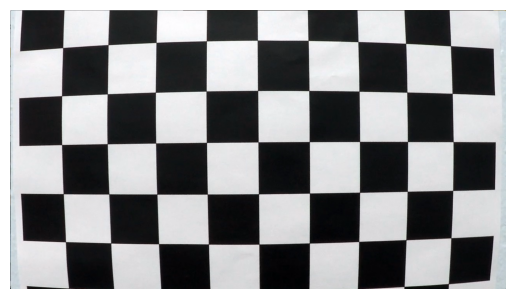

In [13]:
nx = 9
ny = 6
square_size = 20

img = cv.imread('camera_cal/calibration1.jpg',-1) 
plt.imshow(img)
plt.axis('off')  
plt.show()

Inclure la ligne suivante afin de déterminer les critères d'arrêt des itérations considérés dans les algos qu'on utilisera. Ici il s'agit d'effectuer 30 itérations et s'arrêter lorsque la variation entre deux itérations est inférieure à 0.001.

In [8]:
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)


## Etape 2:  Définir les points 3D du damier (monde réel)
Créez une variable patternPoints construit la grille des coins en 3D :
- les coins sont sur un plan, donc Z = 0
- (X = i \cdot square_size), (Y = j \cdot square_size)
- unité : mm
À la fin, patternPoints contient les coordonnées réelles des coins du damier.

In [20]:
patternPoints = np.zeros((ny*nx,3), np.float32)
patternPoints[:,:2] = np.mgrid[0:nx,0:ny].T.reshape(-1,2)
patternPoints = patternPoints * square_size


Vérifier la taille de la variable patternPoints

In [21]:
patternPoints.shape

(54, 3)

## Etape 3: Parcourir toutes les images et détecter les coins (2D)
Pour chaque image dans ./camera_cal/*.jpg :
- Importer les images et convertir en niveau de gris.
- Afficher image par image. Vous pouvez utiliser la fonction *cv.waitKey* pour faire défiler les images



(-0.5, 1279.5, 719.5, -0.5)

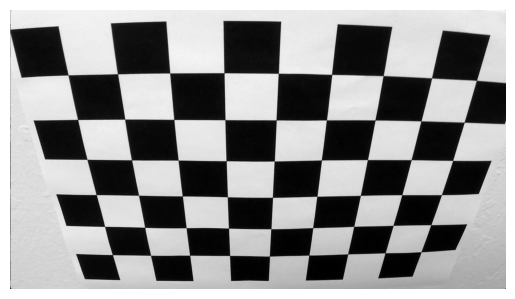

In [42]:
img = cv.imread('camera_cal/calibration2.jpg',-1) 
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.imshow(gray, 'gray')
plt.axis('off')  

Effectuer la détection des coins (cv.findChessboardCorners). 

In [43]:
ret, corners = cv.findChessboardCorners(img, (nx, ny), None)

- Si la détection marche :
    * affiner la position subpixel (cv.cornerSubPix)
    * dessiner les coins pour vérifier visuellement (cv.drawChessboardCorners)
    * stocker :
        * les coins 2D (pixels) → points2D
        * les coins 3D (mm) → points3D

True


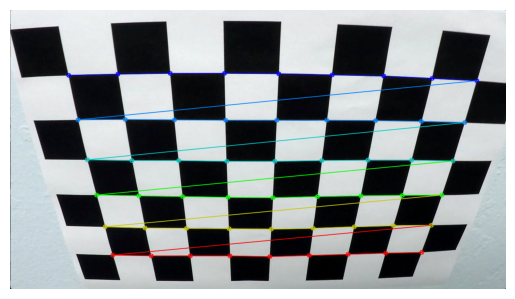

In [ ]:
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

print(ret)

if ret:
        objpoints.append(patternPoints)
        corners2 = cv.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)
        img = cv.drawChessboardCorners(img, (nx, ny), corners2, ret)
        plt.imshow(img, 'gray')
        plt.axis('off')

## Etape 4:  Lancer la calibration 
Après avoir traité les images :
- Récupérer la taille des images :
- Appeler :
    * cv.calibrateCamera(points3D, points2D, (h,w), None, None)
- Afficher la matrice de rotation, les coefficients de distrotions, les vecteurs de rotation et translation

In [51]:
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

print('ret = ', ret)
print('\nK matrix = \n', mtx)
print('\ndist = ', dist)
print('\nrvecs = \n', rvecs)
print('\ntvecs = \n', tvecs)

ret =  0.8763155980728067

K matrix = 
 [[776.32739489   0.         646.10883216]
 [  0.         743.52128378 207.66354986]
 [  0.           0.           1.        ]]

dist =  [[-0.15420147  0.06831197  0.02152689  0.00281603 -0.00623828]]

rvecs = 
 (array([[ 0.39453543],
       [-0.03237547],
       [ 0.01544513]]),)

tvecs = 
 (array([[-73.25314369],
       [ -7.19124354],
       [107.17695271]]),)


## Etape 5: Vérifier la qualité de la calibration

Afin de vérifier si vous avez bien calibré votre caméra, nous allons effectuer ce qui suit:
- reprojetter les points 3D avec cv.projectPoints
- comparer avec les coins détectés points2D
- calculer une erreur moyenne en pixels
- Bonus: appliquer la fonction cv.undistort pour corriger la distorsion d’une image causée par une caméra réelle. Vous pouvez générer les images réctifiées et les sauvegarder dans un autre répertoire.


In [52]:
# A compléter
mean_error = 0
for i in range(len(objpoints)):
    imgpoints2, _ = cv.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
    error = cv.norm(imgpoints[i], imgpoints2, cv.NORM_L2)/len(imgpoints2)
    mean_error += error

print( "total error: {}".format(mean_error/len(objpoints)) )


total error: 0.11925135691836086


## Version Finale:

Regroupez tous les niveaux développés précédemment dans une seule cellule en parcourant l'ensemble des images et en affichant le résultat de calibration ainsi que les images corrigées.

N.B.:Pensez à utiliser la fonction *cv.destroyAllWindows()* pour fermer les fenêtres apparues. 

In [77]:
def calibration(nx,ny,square_size,n):
    patternPoints = np.zeros((ny*nx,3), np.float32)
    patternPoints[:,:2] = np.mgrid[0:nx,0:ny].T.reshape(-1,2)
    patternPoints = patternPoints * square_size

    for i in range(1,n+1):
        print("\nImage ",i)
        path= 'camera_cal/calibration'+str(i)+'.jpg'
        img = cv.imread(path,-1) 
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        ret, corners = cv.findChessboardCorners(img, (nx, ny), None)

        objpoints = [] # 3d point in real world space
        imgpoints = [] # 2d points in image plane.

        if ret:
                objpoints.append(patternPoints)
                corners2 = cv.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
                imgpoints.append(corners2)
                img = cv.drawChessboardCorners(img, (nx, ny), corners2, ret)
                plt.imshow(img, 'gray')
                plt.axis('off')
                plt.show()

                ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
                mean_error = 0
                for i in range(len(objpoints)):
                    imgpoints2, _ = cv.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
                    error = cv.norm(imgpoints[i], imgpoints2, cv.NORM_L2)/len(imgpoints2)
                    mean_error += error

                print( "total error: {}".format(mean_error/len(objpoints)) )

        else: 
             print("ret=False")
        


Image  1
ret=False

Image  2


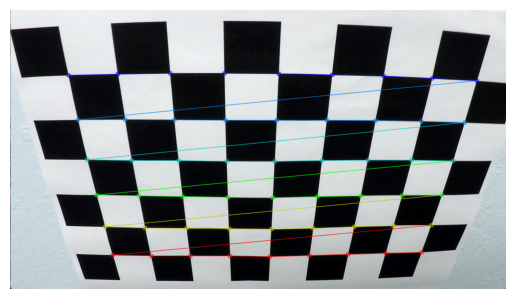

total error: 0.11924951647409845

Image  3


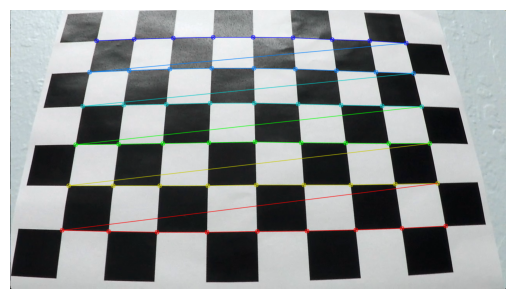

total error: 0.12272095137173188

Image  4
ret=False

Image  5
ret=False

Image  6


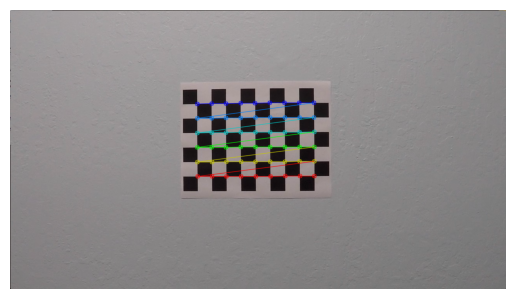

total error: 0.016440201077878674

Image  7


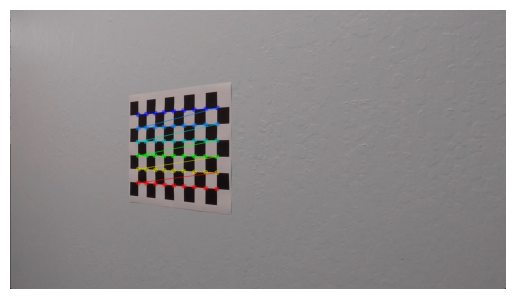

total error: 0.056028271592291005

Image  8


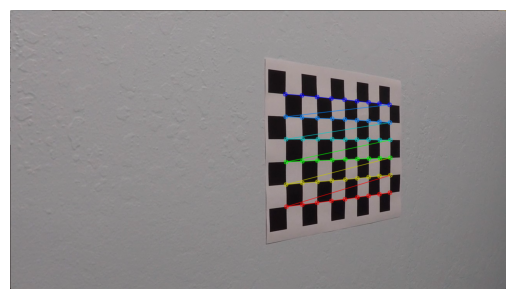

total error: 0.06915722092273745

Image  9


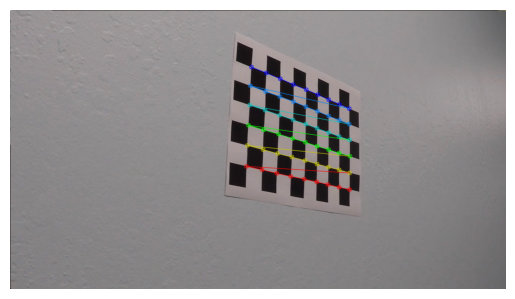

total error: 0.07192227778573927

Image  10


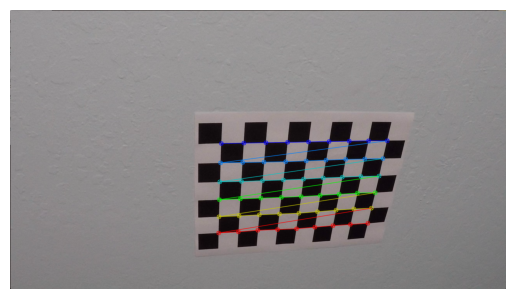

total error: 0.055619486627461995

Image  11


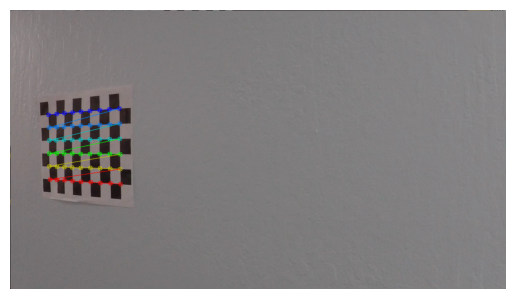

total error: 0.08416265464855813

Image  12


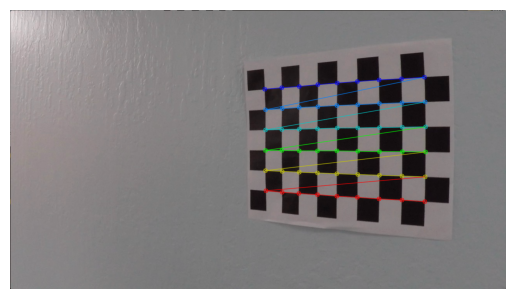

total error: 0.2392467887009617

Image  13


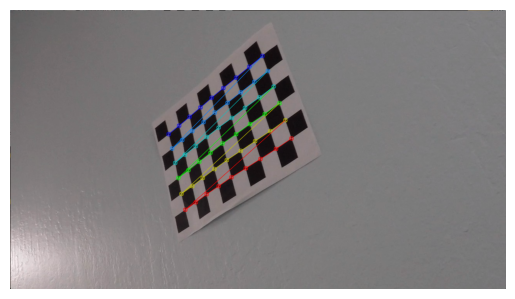

total error: 0.08796904576603345

Image  14


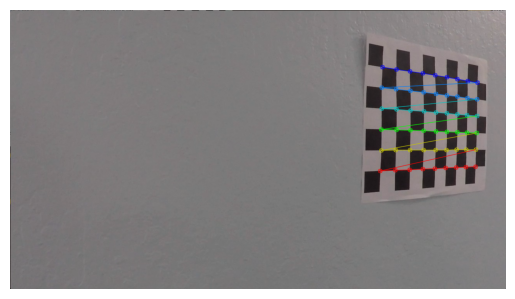

total error: 0.09146305752662943

Image  15


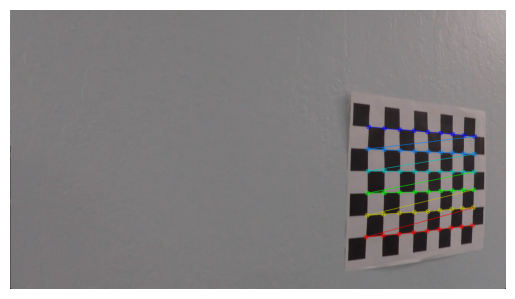

total error: 0.08784669529331725

Image  16


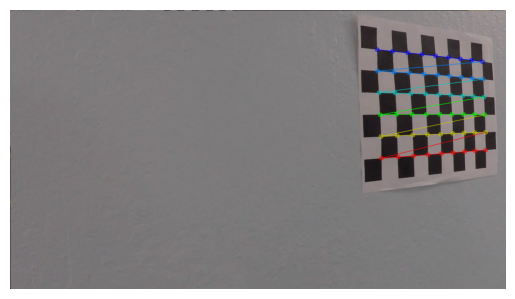

total error: 0.08548154675551174

Image  17


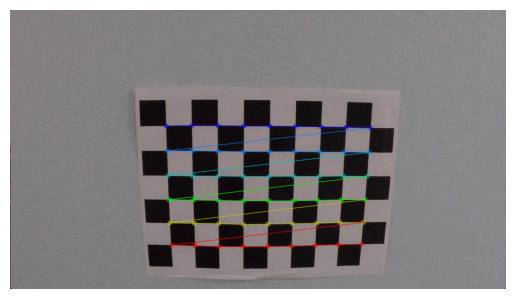

total error: 0.07109409605417084

Image  18


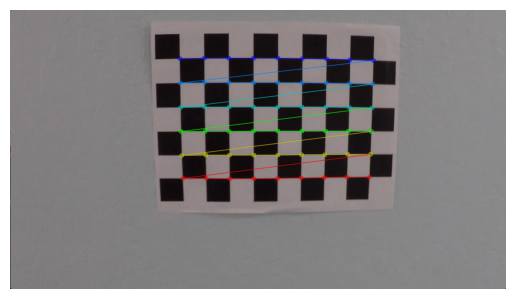

total error: 0.035193896688363625

Image  19


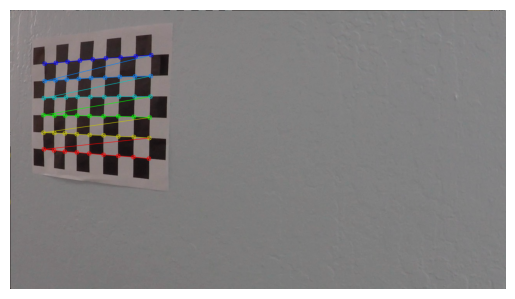

total error: 0.07692800600179052

Image  20


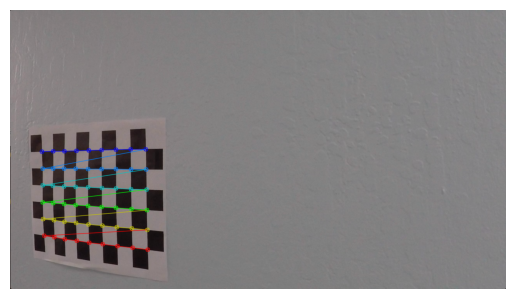

total error: 0.0927586857403248


In [78]:
calibration(nx,ny,square_size,20)